<a href="https://colab.research.google.com/github/toshikis/AISeminar/blob/%E5%BE%A9%E7%BF%92%E7%94%A8%E6%95%99%E6%9D%90/%E7%94%BB%E5%83%8F%E8%AA%8D%E8%AD%98%E2%91%A3%E8%BB%A2%E7%A7%BB%E5%AD%A6%E7%BF%92%E3%81%AB%E3%82%88%E3%82%8B%E7%94%BB%E5%83%8F%E5%88%86%E9%A1%9E_%E8%AC%9B%E5%B8%AB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=#0e89b2>0. ライブラリのインポート</font>

In [ ]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 16.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=b73079b4d2fa920b608a8efbbfbd220a4f233becfd9a1f2670fda07ff0f5b738
  Stored in directory: /root/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize-matplotlib


In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

import cv2
from google.colab.patches import cv2_imshow
import zipfile
import os

import keras
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import decode_predictions, preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


また、今回もランタイムのタイプを「T4 GPU」に変更しておきましょう。

# <font color=#0e89b2>1. 転移学習</font>

## <font color=#0e89b2>1.1 転移学習とは？</font>

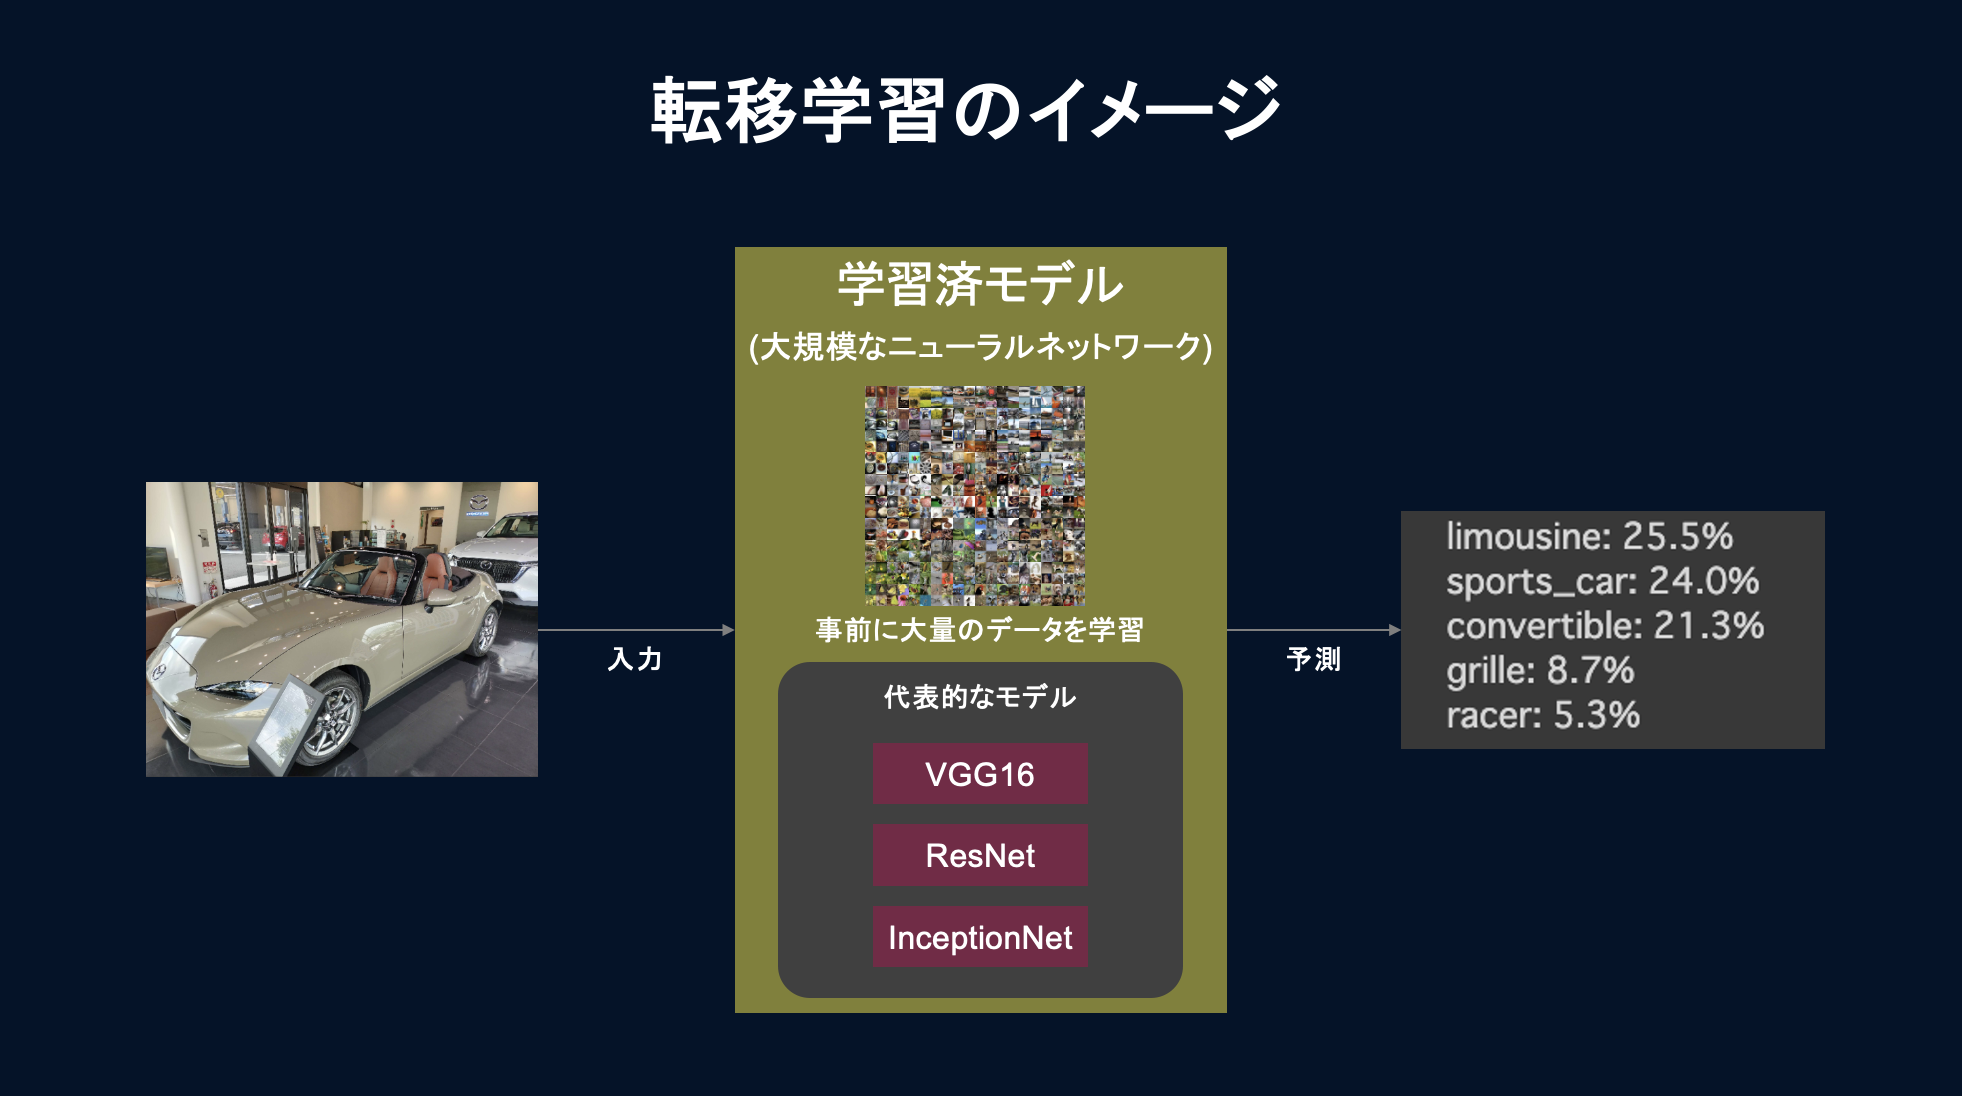

通常新しい画像認識タスクに取り組むときは、大量の画像データを集めて、モデルをゼロから学習させる必要があります。<br>
しかし、これには多くの時間と計算リソースが必要です。<br>
<br>
そこで、事前に大規模なデータセットで学習されたモデル（事前学習済みモデル）を流用して画像認識タスクに取り組む手法があります。<br>
これを「転移学習」といいます。<br>
<br>
※事前学習済みモデル
* 100万枚以上の画像データセット（ImageNet）で学習済
* 数千万から1億以上のパラメータを持つ大規模なニューラルネットワーク

<br>

事前学習済みモデルは、研究機関や大手テクノロジー企業によって提供されています。<br>
さらにKerasでは、様々な事前学習済みモデルが組み込まれており、簡単に利用することができます。<br>
また、これらの事前学習済みモデルの多くは、オープンソースライセンスの下で公開されているので、誰でも自由に利用することができます。<br>
これにより、研究者や開発者は、最先端のディープラーニングモデルを容易に利用し、新しいタスクに適用することができます。

例えばVGG16は、1,000クラスの画像分類を行うように学習された事前学習モデルです。<br>
1,000クラスには、例えば以下のようなラベルが含まれています。

* シーズー (Shih-Tzu)
* コーヒーマグ (Coffee mug)
* ハチドリ (Hummingbird)
* スクールバス (School bus)
* ピザ (Pizza)
* チューリップ (Tulip)
* ラップトップコンピュータ (Laptop computer)
* ゴールデンレトリバー (Golden Retriever)
* 寿司 (Sushi)
* スキー (Ski)

※ちなみに1,000クラスの一覧はこちらから確認できます。<br>
https://image-net.org/challenges/LSVRC/2014/browse-synsets<br>

<br>

このVGG16というモデルを使って、画像分類を行ってみましょう。

## <font color=#0e89b2>1.2 VGG16を利用した転移学習の実装</font>

### <font color=#0e89b2>(1) VGG16の読み込み</font>

VGG16はKerasでモジュールとして組み込まれているので、`import`すれば簡単に読み込むことができます。

In [ ]:
#####写経#####
#ライブラリのインポート
from keras.applications.vgg16 import VGG16

#モデルの読み込み
model = VGG16()

553467096/553467096 [==============================] - 6s 0us/step


モデルの詳細な情報を表示してみます。

In [ ]:
#####写経#####
#モデルの詳細情報を表示
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

出力された情報を見てみると、VGG16は以下のような合計23層を持つ巨大なモデルであることがわかります。<br>
* 13個の畳み込み層（Convolutional Layers）
* 3個の全結合層（Dense Layers）
* 5個のプーリング層（Max Pooling Layers）
* 1個のFlatten層
* 1個の入力層（Input Layer）
* 1個の出力層（Output Layer）

ちなみに名称の「16」は、畳み込み層と全結合層の合計数に由来しています。<br>
また、パラメータ数は1億3千万以上にも上ります。

### <font color=#0e89b2>(2) データの前処理</font>

#### <font color=#0e89b2>a. リサイズ</font>

VGG16は学習時に「224×224」ピクセルの画像で学習しているため、<br>
予測させるデータも「224×224」にリサイズしておく必要があります。<br>
<br>
お馴染みの車の画像を読み込んで、リサイズしましょう。<br>
https://drive.google.com/file/d/1gpmXO9OsJzQwJrHsP-XAII0H1iurtcCC/view?usp=drive_link

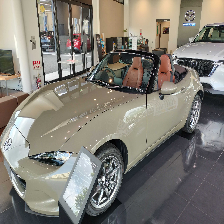

In [ ]:
#####写経#####
img = cv2.imread("/content/car.jpg")
img = cv2.resize(img, (224, 224))
cv2_imshow(img)

#### <font color=#0e89b2>b. 配列の形状の変換</font>

VGG16のモデルに入力するデータは、配列の形状が(1, 224, 224, 3)である必要があります。<br>
これはディープラーニングの理屈どうこうではなく、ただVGG16の仕様がそうなっているというだけなので、<br>
深く考えなくても大丈夫です。<br>
<br>
現在の`img`の配列は(224, 224, 3)なので、これを(1, 224, 224, 3)に変換します。<br>
この変換を行うためには、`np.expand_dims(img, axis=0)`を適用します。

In [ ]:
#####写経#####
#配列の形状の変換
data = np.expand_dims(img, axis=0)

#### <font color=#0e89b2>c. VGG16学習時と同様の前処理</font>

`vgg16.preprocess_input()`を使用すると、VGG16が事前学習時に行なった前処理と同じ処理を1行で実行できます。<br>
具体的には以下のような処理が実行されます。
* 画像データをfloat32型に変換
* 画像データを[0, 255]の範囲から[-1, 1]の範囲にスケーリング
* ImageNetデータセットの平均値（[103.939, 116.779, 123.68]）を各チャンネルから引き算


In [ ]:
#####写経#####
#VGG16学習時と同様の前処理
data = preprocess_input(data)

### <font color=#0e89b2>(3) 予測</font>

(1)で準備したVGG16のモデルを使って、予測を行います。

In [ ]:
#####写経#####
#予測の実行
predicts = model.predict(data)
predicts

1/1 [==============================] - 0s 39ms/step


array([[1.56009410e-08, 1.05260867e-08, 2.83856298e-06, 3.30357437e-07,
        7.42821726e-07, 3.27575185e-06, 2.02617571e-06, 9.10829527e-08,
        1.06357369e-07, 3.18523163e-09, 1.34540343e-08, 2.23791368e-08,
        1.74159283e-08, 6.33593089e-09, 5.46801182e-09, 1.23450326e-08,
        6.10952089e-09, 3.21385123e-08, 1.22695454e-07, 4.72269051e-08,
        3.28090408e-08, 3.86523213e-09, 5.88969336e-08, 2.66108685e-07,
        1.67755907e-08, 4.57794336e-08, 1.20720394e-08, 4.20793178e-09,
        2.27334631e-08, 1.30451721e-08, 2.57313076e-07, 1.29078984e-07,
        1.32788699e-07, 1.36300332e-06, 7.28446275e-06, 1.97929523e-07,
        1.16966282e-06, 2.24253569e-07, 4.86003309e-08, 4.38556000e-08,
        3.95483539e-08, 7.59436336e-09, 1.24024542e-08, 1.40419516e-08,
        2.72063172e-08, 5.10679179e-08, 2.61830326e-08, 4.95885555e-09,
        2.39872122e-07, 1.30887940e-07, 5.80816447e-07, 1.09331711e-06,
        9.97514160e-09, 9.89290783e-09, 1.64116713e-07, 1.099737

この出力結果をみてもよくわかりません。<br>
これをさらに理解できる形式に変換するためには、`keras.applications.vgg16.decode_predictions`を使用します。

In [ ]:
#####写経#####
results = decode_predictions(predicts, top=5)[0]
results

[('n03670208', 'limousine', 0.25362843),
 ('n04285008', 'sports_car', 0.24256387),
 ('n03100240', 'convertible', 0.21362178),
 ('n03459775', 'grille', 0.08818127),
 ('n04037443', 'racer', 0.051920637)]

リムジンは別として、スポーツカー、コンバーチブルと確からしい予測結果が並んでいます。<br>
数値は、そのカテゴリに属する確率値を表しています。<br>
蛇足ですがもう少し見やすい形式に変換してみます。

In [ ]:
#####写経#####
for r in results:
  name = r[1]
  probability = r[2]
  print(name, "：", round(probability*100), "%")

limousine ： 25 %
sports_car ： 24 %
convertible ： 21 %
grille ： 9 %
racer ： 5 %


## <font color=#0e89b2>1.3 練習問題</font>

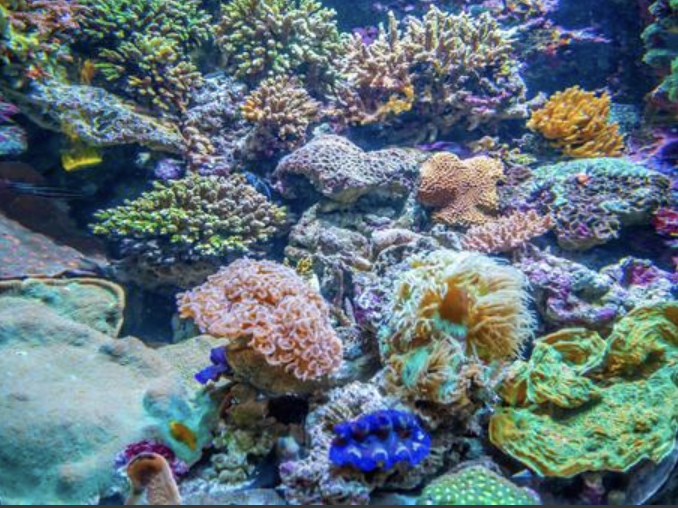

VGG16の事前学習モデルを利用して、以下の画像が1,000クラスのうちのどれにあたるか予測を行なってください。<br>
画像は全部で8件あります。

https://drive.google.com/file/d/1AJgG4uX-rZeH4qU_mwYan5xt26vzoFfr/view?usp=drive_link

解答

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with zipfile.ZipFile('/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/pictures.zip','r') as inputFile:
    inputFile.extractall("pictures")

In [ ]:
folder_path = "/content/pictures/pictures"
#フォルダ内のJPEGファイルを取得
jpeg_files = [f for f in os.listdir(folder_path)]
jpeg_files

['coral.jpg',
 'ball.jpg',
 'guitar.jpg',
 'Mont_Blanc.jpg',
 'corry.jpg',
 'pineapple.jpg',
 'camera.jpg',
 'airplane.jpg']

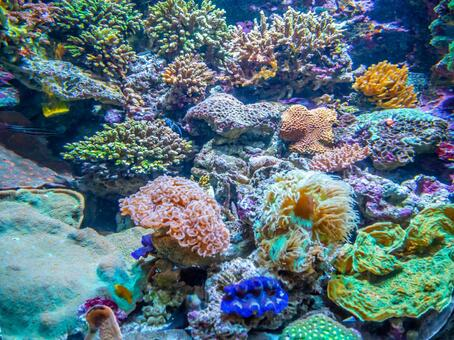

35363/35363 [==============================] - 0s 0us/step
coral_reef: 93.1%
anemone_fish: 1.4%
rock_beauty: 1.0%
brain_coral: 0.8%
lionfish: 0.6%


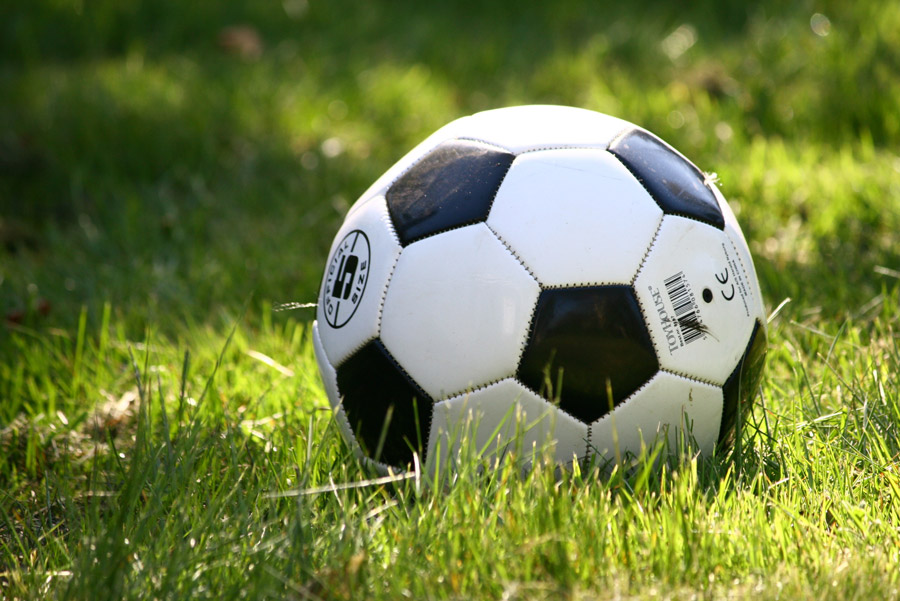

1/1 [==============================] - 1s 791ms/step
soccer_ball: 100.0%
volleyball: 0.0%
rugby_ball: 0.0%
football_helmet: 0.0%
giant_panda: 0.0%


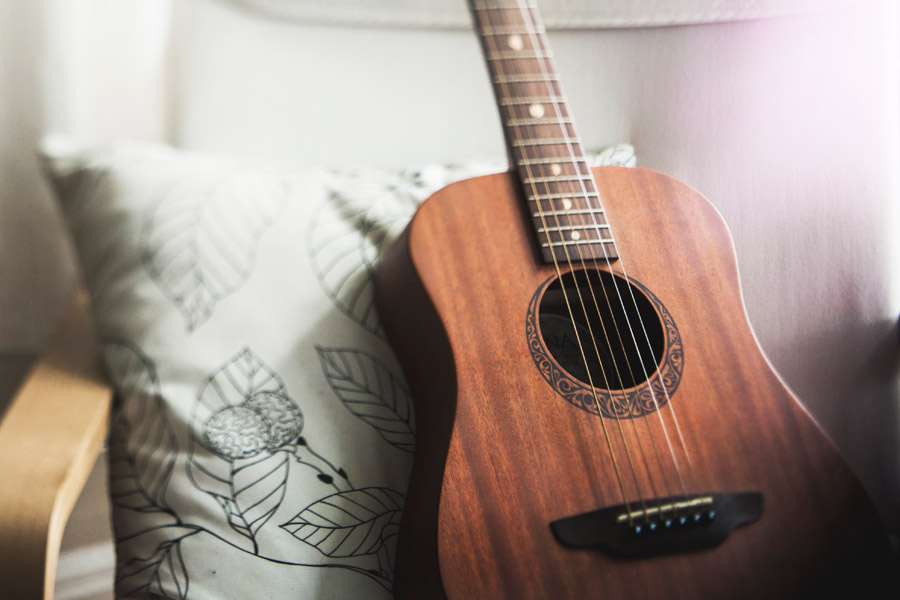

1/1 [==============================] - 1s 802ms/step
acoustic_guitar: 84.1%
electric_guitar: 12.9%
banjo: 0.8%
pick: 0.2%
vacuum: 0.2%


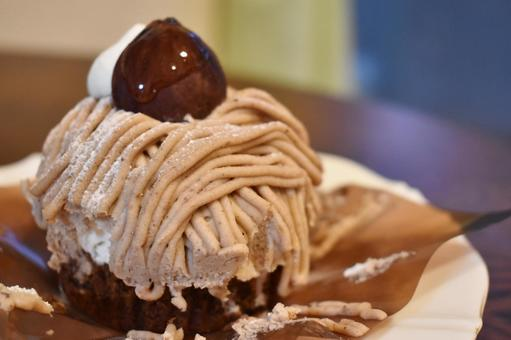

1/1 [==============================] - 2s 2s/step
swab: 22.8%
knot: 6.5%
paintbrush: 3.6%
ski_mask: 2.9%
lionfish: 2.1%


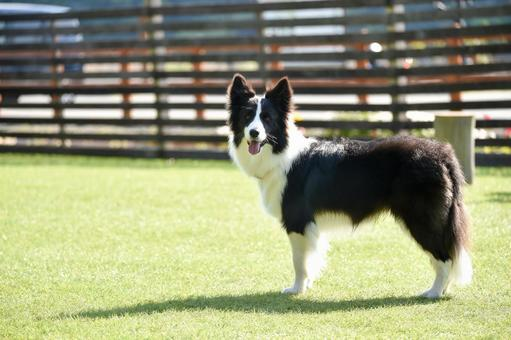

1/1 [==============================] - 1s 790ms/step
Border_collie: 23.0%
Siberian_husky: 17.9%
Eskimo_dog: 17.4%
collie: 9.6%
llama: 5.2%


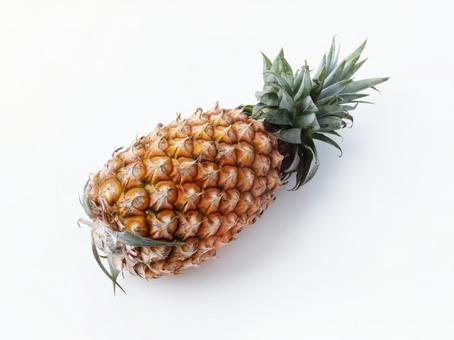

1/1 [==============================] - 1s 1s/step
pineapple: 78.2%
acorn: 3.9%
maraca: 3.1%
knot: 2.9%
strawberry: 1.6%


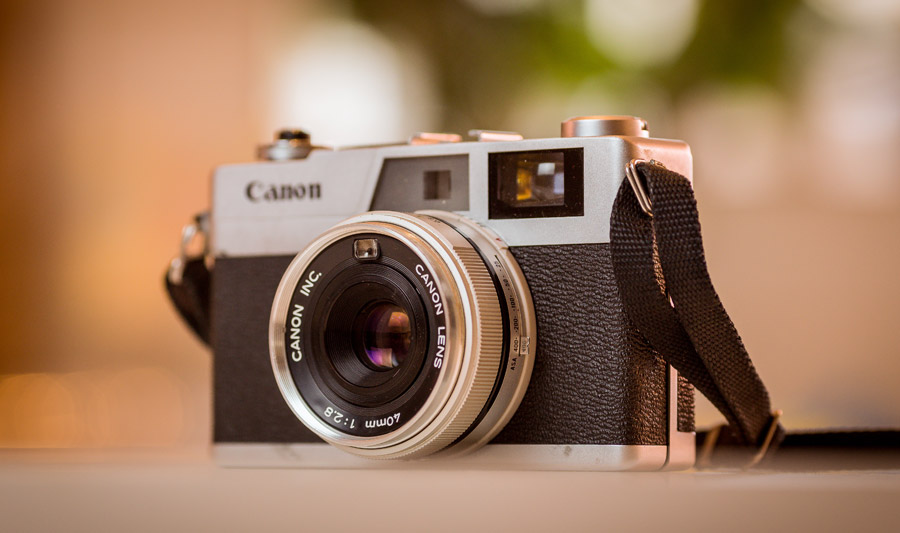

1/1 [==============================] - 2s 2s/step
reflex_camera: 57.2%
Polaroid_camera: 41.0%
lens_cap: 0.6%
projector: 0.5%
tripod: 0.4%


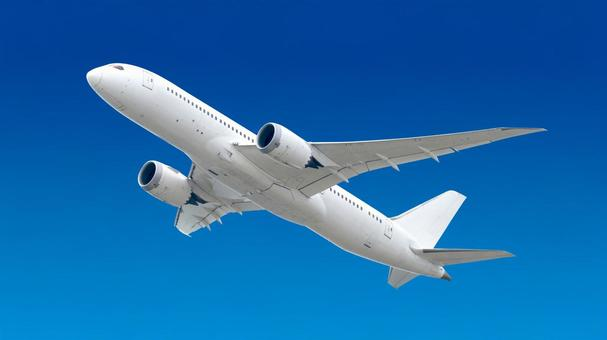

1/1 [==============================] - 2s 2s/step
warplane: 56.0%
airliner: 29.3%
wing: 6.7%
missile: 3.1%
projectile: 3.0%


In [ ]:
for jpeg_file in jpeg_files:
  #ファイルの読み込み
  file_path = os.path.join(folder_path, jpeg_file)
  data = cv2.imread(file_path)
  cv2_imshow(data)
  #データの前処理
  data = cv2.resize(data, (224, 224))
  data = np.expand_dims(data, axis=0)
  data = preprocess_input(data)
  #予測
  predicts = model.predict(data)
  results = decode_predictions(predicts, top=5)[0]
  for r in results:
    name = r[1]
    pct = r[2]
    print(f"{name}: {pct:.1%}")

この中では、実はモンブラン（ケーキ）のみVGG16の事前学習時の1000クラスに含まれていません。<br>
ですのでモンブランだけは、無茶苦茶な予測結果が出てきます。<br>
しかしその他の7件は、ある程度妥当な予測結果が出てきているはずです。

# <font color=#0e89b2>2. ファインチューニング</font>

## <font color=#0e89b2>2.1 ファインチューニングとは？</font>

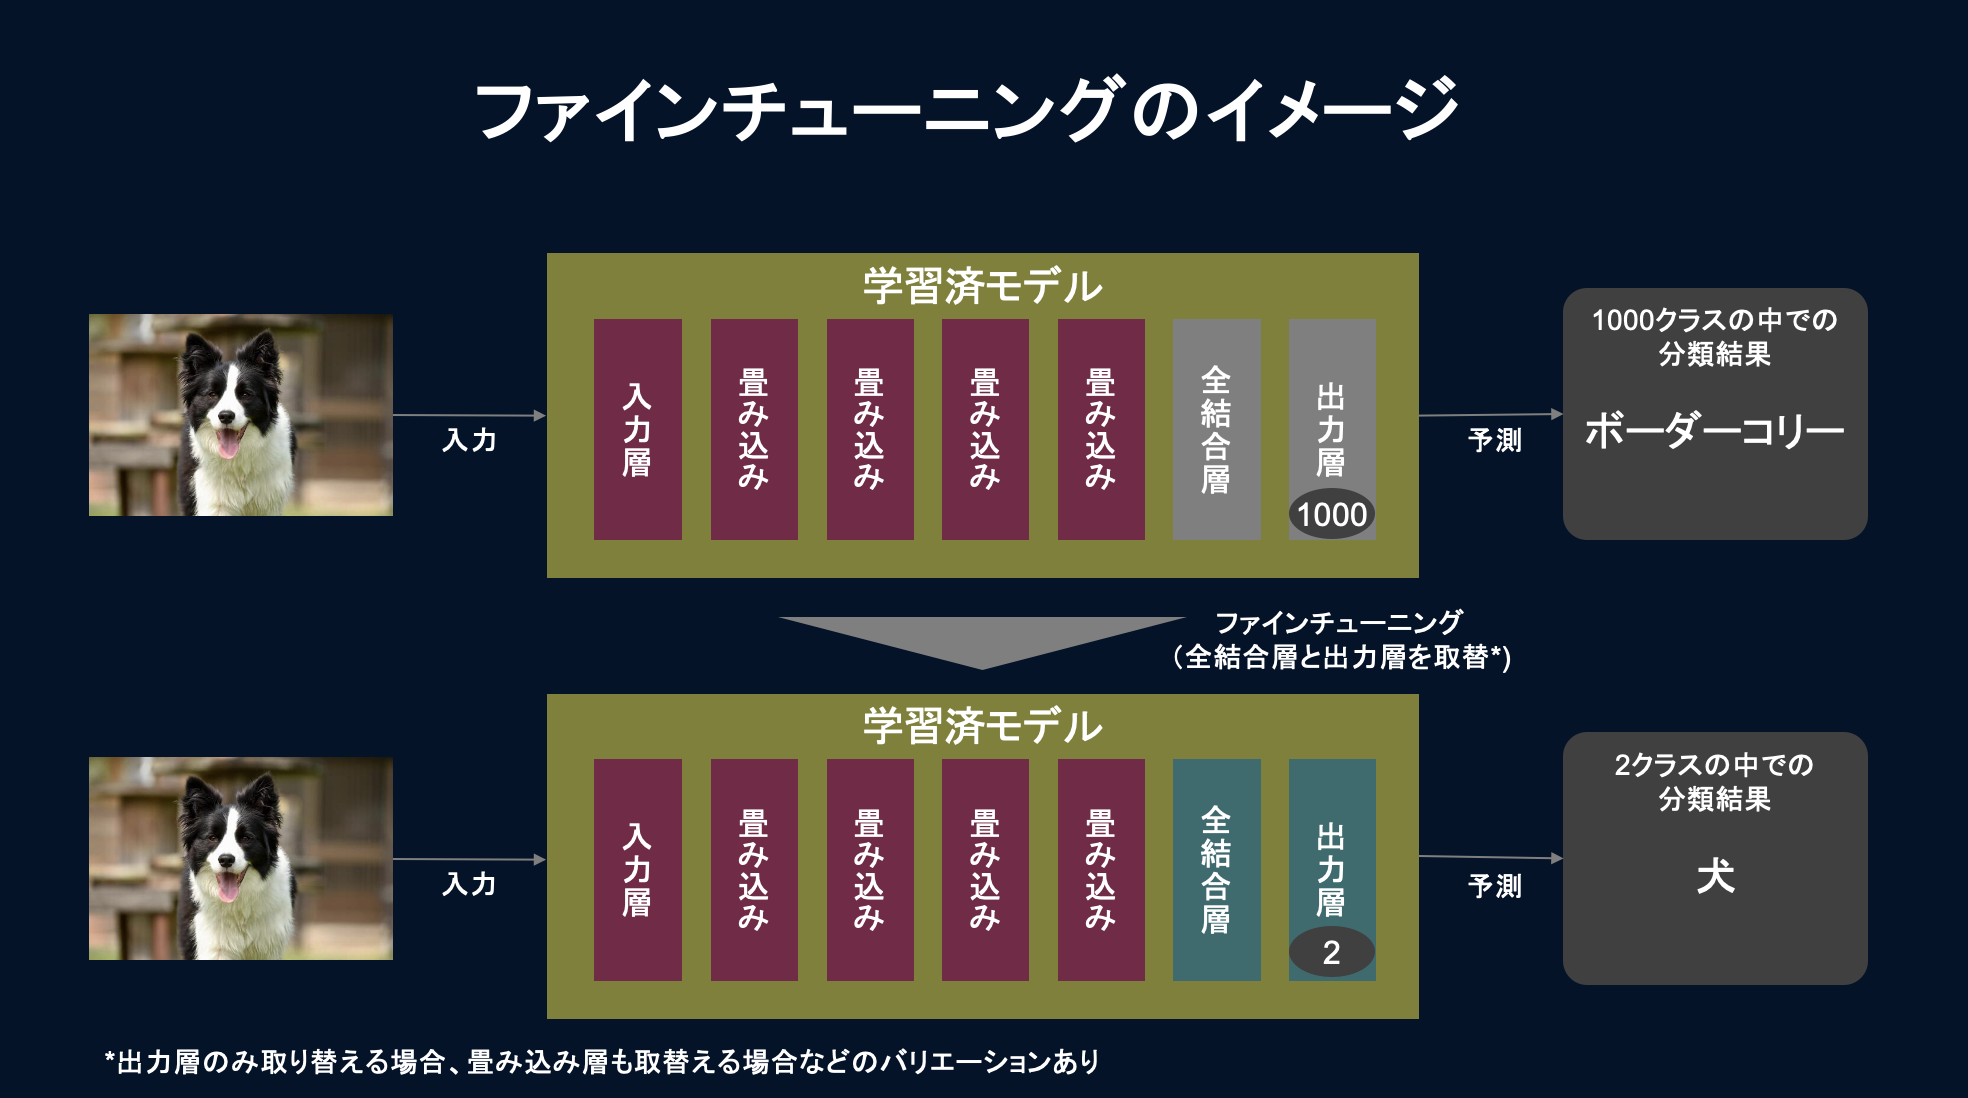

おさらいですがVGG16は、例えば以下のような1,000クラスの画像分類を行う事前学習モデルでした。<br>

* シーズー (Shih-Tzu)
* コーヒーマグ (Coffee mug)
* ハチドリ (Hummingbird)
* スクールバス (School bus)
* ピザ (Pizza)
* チューリップ (Tulip)
* ラップトップコンピュータ (Laptop computer)
* ゴールデンレトリバー (Golden Retriever)
* 寿司 (Sushi)
* スキー (Ski)

このVGG16を利用して「犬or猫」の二値分類タスクに取り組むケースを考えてみます。<br>
1,000クラスのラベルは、「犬」「猫」というざっくりした括りではなく、<br>
「シーズー」「ゴールデンレトリーバー」などのもっと細かい品種でカテゴライズされているため、<br>
このモデルをそのまま流用しても「犬or猫」の二値分類タスクを解くことはできません。<br>
<br>
そこで、VGG16の出力層（1,000クラスの分類を行う層）を取り除き、代わりに「犬or猫」の二値分類を行う新しい出力層を追加します。<br>
そしてこの新たなモデルに「犬or猫」の正解ラベルつきのデータを学習させることで、<br>
「犬猫二値分類」タスクを解けるようにモデルをアップデートします。<br>
<br>
このように、事前学習済みモデルの一部を変更し、新しいタスクに適応させることを「ファインチューニング」と呼びます。
<br>
（なお出力層だけでなく、全結合層や畳み込み層も取り替えるケースも往々にしてあります。）<br>
<br>
ファインチューニングでは、通常、事前学習済みモデルの初期の層（特徴抽出を行う層）の重みは固定し、<br>
新しく追加した層やモデルの後半部分の層の重みのみを学習します。<br>
これは、初期の層が汎用的な特徴を抽出しているため、そのまま活用できると考えられているためです。

## <font color=#0e89b2>2.2 ファインチューニングの実装</font>

VGG16をファインチューニングして、「画像認識③」で取り組んだ「犬猫分類」のタスクに再びチャレンジしてみます。

### <font color=#0e89b2>(1) データの読み込み</font>

データはこちらからダウンロードできます。<br>
https://drive.google.com/file/d/1sNPNWLSvcgxGHd7Homhbwz_Z_2dK2S7a/view?usp=drive_link<br>
<br>
このファイルを読み込んで解凍しましょう。

In [ ]:
#####写経#####
#trainデータのZIPファイルを解凍
with zipfile.ZipFile('/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/dogs_and_cats.zip','r') as inputFile:
    inputFile.extractall("dogs_and_cats")

### <font color=#0e89b2>(2) データの前処理</font>

#### <font color=#0e89b2>a. ImageDataGeneratorとは？</font>

データを前処理していきますが、ここで大切なKerasの`ImageDataGenerator`というツールについて説明します。<br>
<br>
VGG16は非常に大規模なモデルです。<br>
ここに「画像認識③」で行なったように、そのままarray形式の大量のデータをぶち込むと、<br>
メモリが足りなくなってこのようなエラーが出てきます。<br>

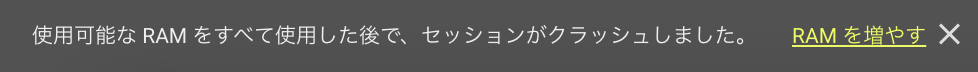

そこで`ImageDataGenerator`を使用します。<br>
ImageDataGeneratorを使うと、データをバッチ単位で読み込んでメモリに保持するので、<br>
大規模なデータセットを扱ってもクラッシュしにくくなります。<br>
<br>
例えば、100万枚の画像データがあるとします。<br>
一度に全部読み込もうとするとメモリが足りなくなり、処理ができなくなってしまいます。<br>
しかしImageDataGeneratorを使えば、例えば1000枚ずつ読み込むことができます。<br>
最初の1000枚を読み込んで処理し、次の1000枚を読み込んで処理し、という具合に進めていきます。

#### <font color=#0e89b2>b. ImageDataGeneratorの準備</font>

`ImageDataGenerator`は、フォルダを指定してそのままフォルダ内のファイルを読み込むことができます。<br>
さらに、画像サイズなどを指定すれば、あとはVGG16に入力できる形式に自動でデータを前処理してくれます。<br>
<br>
つまりImageDataGeneratorは、「ディレクトリ構造に従ってデータを読み込み、指定された前処理を自動的に行い、モデルへ供給するデータを生成する」という一連の処理を実行してくれることになります。<br>
<br>
まずはデータジェネレータのインスタンスを生成します。<br>
学習データ用とテストデータ用のそれぞれのデータジェネレータを作成します。

In [ ]:
#####写経#####
#データジェネレータの生成
train_data_generator = ImageDataGenerator(rescale=1.0/255) #rescaleの指定で正規化処理も行っておく
test_data_generator = ImageDataGenerator(rescale=1.0/255) #rescaleの指定で正規化処理も行っておく

次に、読み込むフォルダ（ディレクトリ）を指定します。

In [ ]:
#####写経#####
train_dir = "/content/dogs_and_cats/dogs_and_cats/train"
valid_dir = "/content/dogs_and_cats/dogs_and_cats/test"

先ほど作ったデータジェネレータに`flow_from_directory`メソッドを適用して、<br>
データのロードと前処理を実行します。<br>
<br>
なお、`flow_from_directory`は指定したディレクトリにあるフォルダの数をクラス数として認識し、自動でラベリングをしてくれます。<br>
例えば今、フォルダ構成は下の画像のようになっているはずです。<br>
各フォルダにはjpg形式の画像ファイルが格納されています。<br>
このうち、例えば`train`については`cats`のフォルダ内の画像を「猫(0)」、`dogs`のフォルダ内の画像を「犬(1)」と自動で正解ラベルをつけて、学習データとして準備してくれます。
<br>

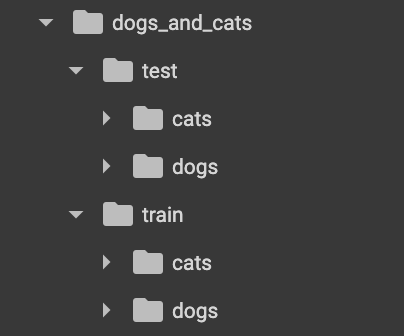

今回は二値分類問題なので、`class_mode`を`binary`に設定しておきます。<br>
多値分類問題になった場合は、`categorical`を指定します。

In [ ]:
#####写経#####
#データのロードと前処理を実行
train_generator = train_data_generator.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

test_generator = test_data_generator.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### <font color=#0e89b2>(3) モデルの構築</font>

#### <font color=#0e89b2>a. VGG16の読み込み</font>

次にモデルを構築していきます。<br>
まずはベースとなる学習済モデルのVGG16を読み込みます。<br>
引数の意味は下記の通りです。
* weights='imagenet'
 * ImageNetデータセットで事前学習された重み係数を読み込むことを指定しています。
 * 転移学習のベースとしてこの重み係数を使用します。
* include_top=False
 * VGG16のネットワーク構造の最後にある3つの全結合層を含めないよう指定しています。
 * 通常、転移学習ではこの部分を別のタスク用に作り直します。
* input_shape=(224, 224, 3)
 * モデルへの入力サイズを(高さ224ピクセル、幅224ピクセル、チャンネル数3(RGBカラー))と指定しています。
 * VGG16はこの入力サイズを前提としているため、この設定が必要です。

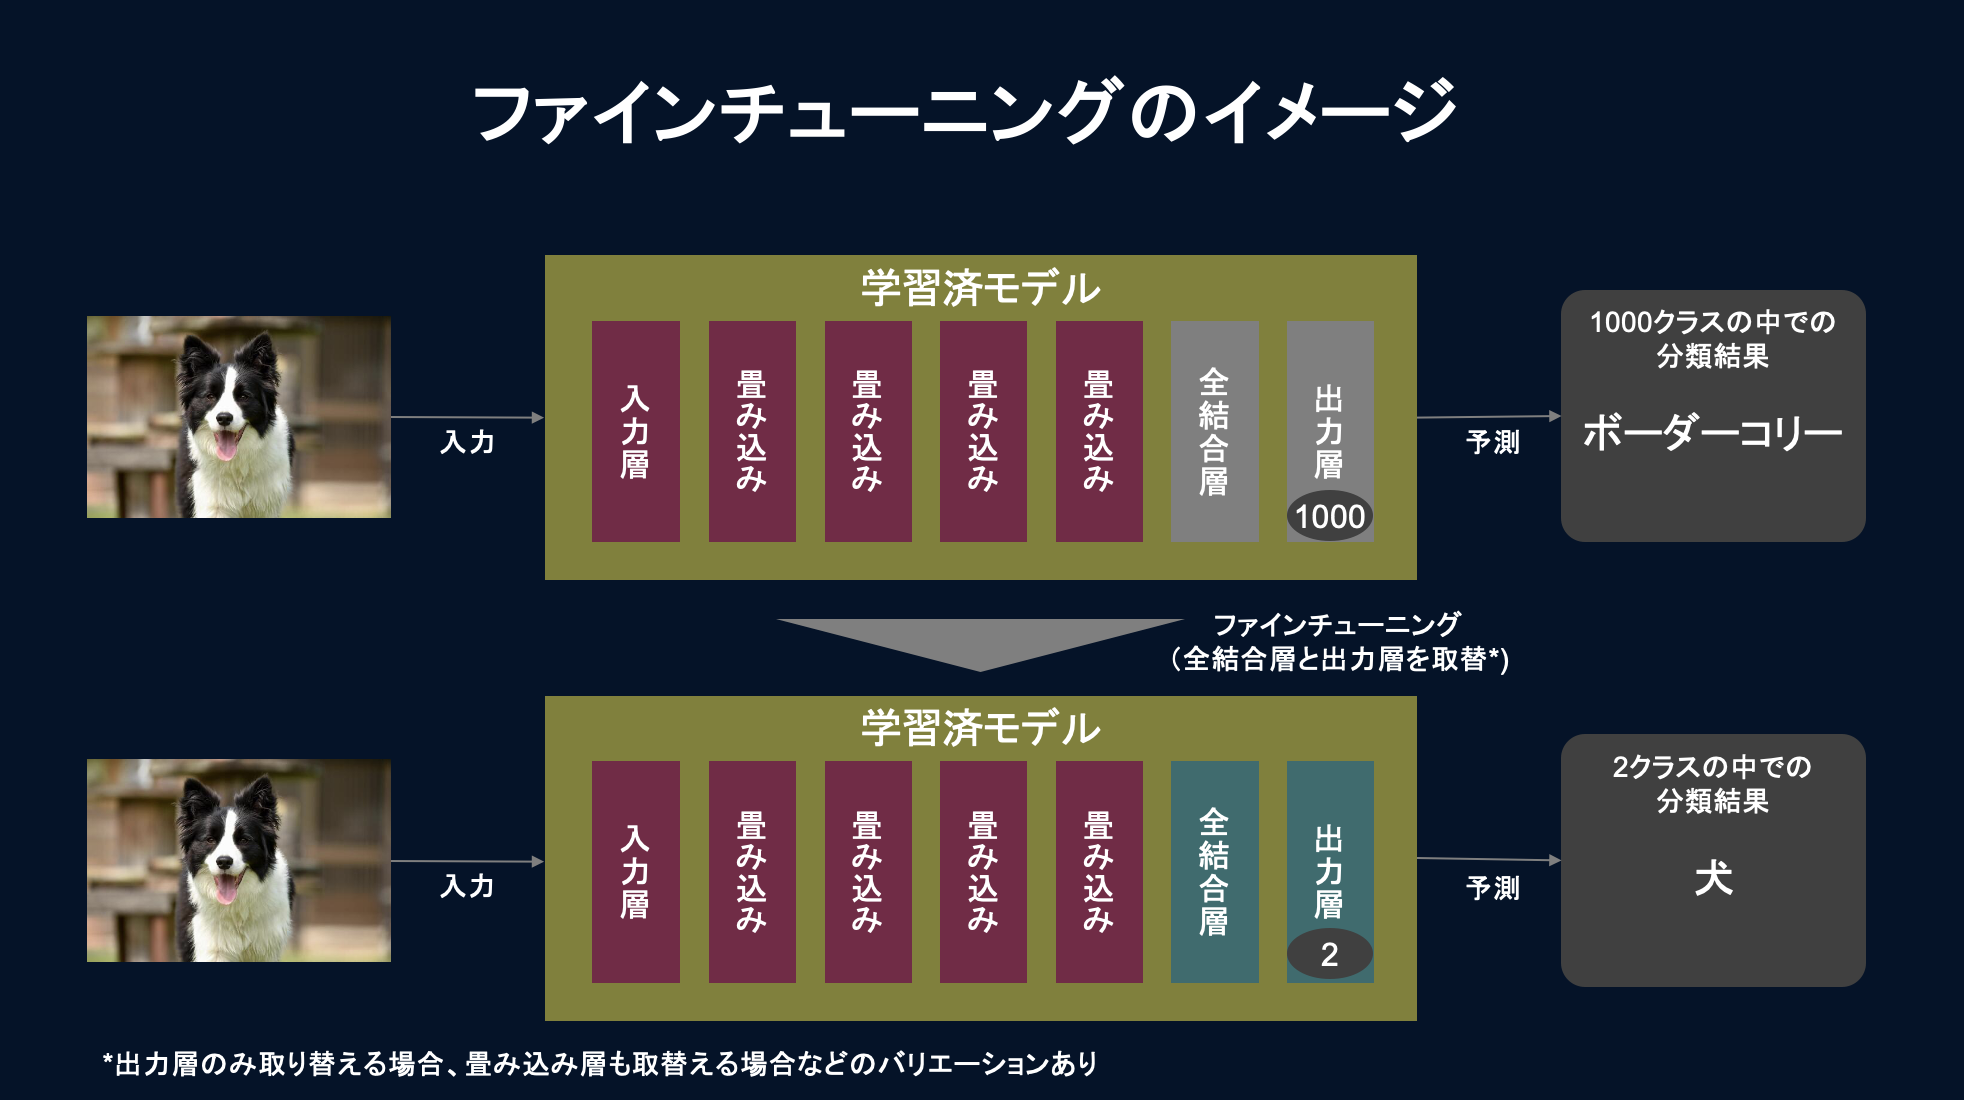

ここで特に重要なのが、`include_Top=False`の指定です。<br>
この指定によって、VGG16のモデルの「トップ層」つまり全結合層と出力層の部分が読み込まれず、<br>
入力層と畳み込みブロックの部分のみが読み込まれることになります。:

In [ ]:
#####写経#####
#事前学習済みのVGG16モデルを読み込む（全結合層は除く）
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 [==============================] - 0s 0us/step


念の為モデルの構造を確認してみます。

In [ ]:
#####写経#####
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

出力を見ると分かる通り、全結合層と出力層の部分が読み込まれず、入力層と畳み込みブロックの部分のみが読み込まれています。

#### <font color=#0e89b2>b. 凍結</font>

このモデルに犬猫のデータをさらに学習させてチューニングしていくわけですが、<br>
全てのパラメータを更新するわけではなく、既存のVGG16モデル内のパラメータはそのままで、<br>
新しく取り付ける全結合層と出力層のパラメータのみ学習によって更新させることにします。<br>
<br>
そこで、VGG16の既存パラメータは新たに更新されないように設定しておきます。<br>
この作業を「凍結」と言います。

In [ ]:
#####写経#####
#事前学習済みの畳み込み層の重みを固定（ファインチューニングしない層）
base_model.trainable = False

ちなみにVGG16の既存パラメータも更新するように学習させる場合もあります。<br>
例えば、4つ目の畳み込みブロックまで（つまり15層目まで）は凍結して、<br>
それ以降は更新されるようにしたい場合は、以下のようにコーディングします。

In [ ]:
# #5つ目の畳み込みブロックより前のパラメータを固定
# for layer in vgg16_model.layers[:15]:
#   layer.trainable = False

#### <font color=#0e89b2>c. モデルの組み替え</font>

それでは、先ほど削除してしまった全結合層と出力層はどのように新しく追加すれば良いかというと、<br>
おなじみの`model.add`を行えばよいです。

In [ ]:
#####写経#####
#全結合層と出力層を追加
model = keras.models.Sequential() #モデルの「箱」を作成
model.add(base_model) #VGG16のベースモデルを追加
model.add(Flatten()) #Flatten層を追加
model.add(Dense(256, activation='relu')) #全結合層を追加
model.add(Dropout(0.5)) #ドロップアウトを設定
model.add(Dense(2, activation='softmax')) #出力層を追加

#### <font color=#0e89b2>d. 学習と評価</font>

それでは学習と評価を行っていきます。<br>
まずは損失関数と正解率を可視化するためのおなじみの関数を準備しておきます。

In [ ]:
def plot_history(history):
    # 損失と精度の履歴を取得
    loss = history.history['loss']
    accuracy = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    # 損失の可視化
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='Training loss')
    plt.plot(epochs, val_loss, label='Validation loss')
    plt.title('損失の推移')
    plt.xlabel('学習回数')
    plt.ylabel('損失')
    plt.legend()

    # 精度の可視化
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='Training accuracy')
    plt.plot(epochs, val_accuracy, label='Validation accuracy')
    plt.title('正解率の推移')
    plt.xlabel('学習回数')
    plt.ylabel('正解率')
    plt.legend()

さらに、こちらもお馴染みの`model.compile`と`model.fit`を実行していきます。<br>
学習データとテストデータは、以下のコードのように`train_generator`と`test_generator`をそのまま渡します。

Epoch 1/10
63/63 [==============================] - 14s 211ms/step - loss: 0.9749 - accuracy: 0.7635 - val_loss: 0.2694 - val_accuracy: 0.8890
Epoch 2/10
63/63 [==============================] - 13s 209ms/step - loss: 0.2596 - accuracy: 0.8925 - val_loss: 0.2306 - val_accuracy: 0.9090
Epoch 3/10
63/63 [==============================] - 13s 199ms/step - loss: 0.1861 - accuracy: 0.9300 - val_loss: 0.2099 - val_accuracy: 0.9110
Epoch 4/10
63/63 [==============================] - 14s 219ms/step - loss: 0.1269 - accuracy: 0.9535 - val_loss: 0.2146 - val_accuracy: 0.9040
Epoch 5/10
63/63 [==============================] - 13s 199ms/step - loss: 0.0971 - accuracy: 0.9700 - val_loss: 0.3239 - val_accuracy: 0.8820
Epoch 6/10
63/63 [==============================] - 14s 216ms/step - loss: 0.1303 - accuracy: 0.9445 - val_loss: 0.2278 - val_accuracy: 0.9050
Epoch 7/10
63/63 [==============================] - 12s 196ms/step - loss: 0.0735 - accuracy: 0.9750 - val_loss: 0.2282 - val_accuracy: 0.9150

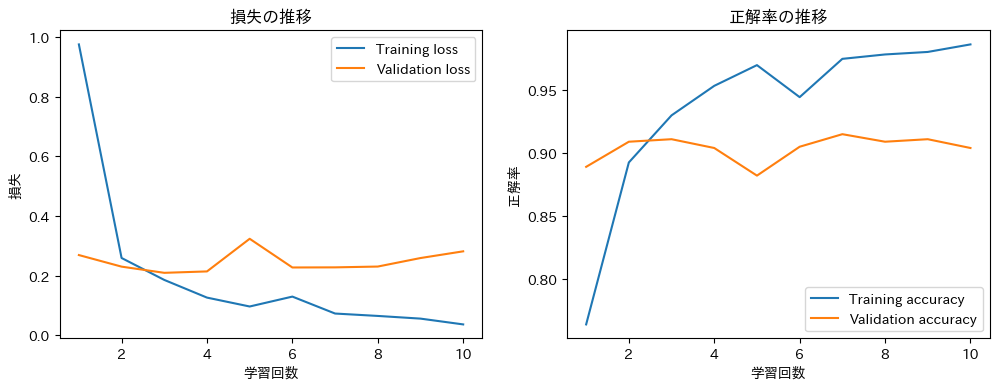

In [ ]:
#####写経#####
# モデルのコンパイル
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#学習
history = model.fit(
    x=train_generator,
    validation_data=test_generator,
    epochs=10
)

# #評価
plot_history(history)
loss, accuracy = model.evaluate(test_generator)
print("正解率：", accuracy)

このように、やや過学習気味ではあるものの、精度約90%まで引き上げることができました。<br>
「画像認識③」のパートで作ったCNNモデルでは精度70%前後だったので、かなりの進歩です。

# <font color=#0e89b2>3. データの水増し</font>

実は先ほど使用した`ImageDataGenerator`は、データの水増し機能も持っている優れものです。<br>
ですのでまとめておくと、`ImageDataGenerator`は以下のような機能を持っていることになります。
* データのバッチ処理（大量データを一気に読み込むことによるクラッシュの防止）
* ディレクトリからのファイルの読み込み
* データのラベリング
* VGG16等の学習済モデルに入力するためのデータの前処理
* New)データの水増し

今回はすでに90%の精度が出ているので改善幅は少ないかもしれませんが、<br>
練習のため実際に水増し処理をコーディングしてみます。<br>
<br>
使い方は、先ほどの`ImageDataGenerator`の関数の引数に、水増し処理のオプションを追記してあげるだけです。

In [ ]:
#####写経#####
#学習データの水増し機能も持つデータジェネレータを生成
train_data_generator = ImageDataGenerator(rescale=1.0/255, #正規化
                                          rotation_range=30, #±30度の範囲内で回転
                                          width_shift_range=0.2, #±20%の範囲内で並行移動
                                          height_shift_range=0.2, #±20%の範囲内で垂直移動
                                          zoom_range=0.5,  #±50%のズーム倍率で拡大縮小
                                          horizontal_flip=True #左右反転
                                          )

test_data_generator = ImageDataGenerator(rescale=1.0/255)

ここから先は、先ほどの実装と何も変わりません。<br>
実行していきましょう。

In [ ]:
#####写経#####
train_dir = "/content/dogs_and_cats/dogs_and_cats/train"
valid_dir = "/content/dogs_and_cats/dogs_and_cats/test"

In [ ]:
#####写経#####
# ディレクトリからデータを生成
train_generator = train_data_generator.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

test_generator = test_data_generator.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Epoch 1/20
63/63 [==============================] - 43s 631ms/step - loss: 1.3757 - accuracy: 0.6610 - val_loss: 0.3661 - val_accuracy: 0.8510
Epoch 2/20
63/63 [==============================] - 33s 527ms/step - loss: 0.4707 - accuracy: 0.7680 - val_loss: 0.3029 - val_accuracy: 0.8730
Epoch 3/20
63/63 [==============================] - 34s 533ms/step - loss: 0.4748 - accuracy: 0.7730 - val_loss: 0.2734 - val_accuracy: 0.8940
Epoch 4/20
63/63 [==============================] - 33s 529ms/step - loss: 0.4416 - accuracy: 0.7975 - val_loss: 0.3626 - val_accuracy: 0.8050
Epoch 5/20
63/63 [==============================] - 33s 525ms/step - loss: 0.4396 - accuracy: 0.7980 - val_loss: 0.2509 - val_accuracy: 0.9080
Epoch 6/20
63/63 [==============================] - 34s 542ms/step - loss: 0.4402 - accuracy: 0.7900 - val_loss: 0.2515 - val_accuracy: 0.9060
Epoch 7/20
63/63 [==============================] - 33s 529ms/step - loss: 0.4152 - accuracy: 0.8135 - val_loss: 0.2132 - val_accuracy: 0.9220

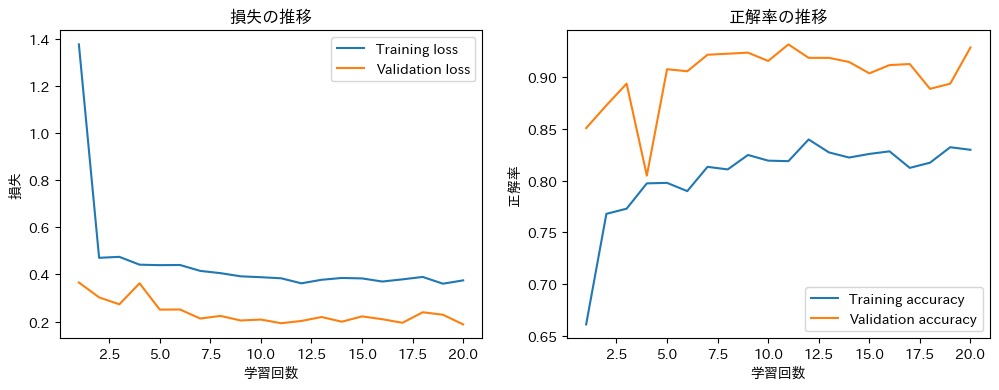

In [ ]:
#####写経#####
# 事前学習済みのVGG16モデルを読み込む（全結合層は除く）
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 全結合層を構築
model = keras.models.Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

# 事前学習済みの畳み込み層の重みを固定（ファインチューニングしない層）
base_model.trainable = False

# モデルのコンパイル
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#学習
history = model.fit(
    x=train_generator,
    validation_data=test_generator,
    epochs=20 #データ量が増加するため、エポック数も引き上げ
)

# #評価
plot_history(history)
loss, accuracy = model.evaluate(test_generator)
print("正解率：", accuracy)

実行するたびに結果は変わりますが、データ水増し前よりも平均して1〜3%ほど正解率が向上するはずです。<br>
<br>



---
■補足<br>
この処理によって実際に何枚のデータが水増しされたのか気になるかもしれませんが、<br>
実際には「1,000枚のデータを水増ししました」という単純な話ではなく、以下のようなカラクリになります。

* 各エポックで、ImageDataGeneratorは元の学習データに対して指定した変形処理(回転、ズーム、反転など)を適用し、その変形画像を使って学習を行います
* つまり、ImageDataGeneratorを使っても、学習データの総件数は変わりません。ただし、各エポックで異なる変形が適用されるため、実質的には異なる画像が使われることになります

<br>

ただしコードの書き方を変えれば、「実際に1,000枚のデータを新しく変形生成して、それをモデルに学習させる」<br>
という処理を行うこともできます。

---



# <font color=#0e89b2>4. 総合問題：花</font>

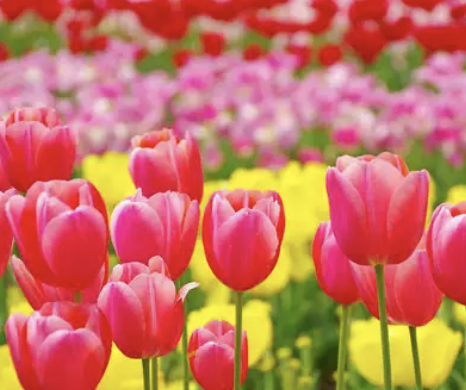

VGG16をファインチューニングして、以下の5種類の花を分類するモデルを作成してください。<br>
学習データとテストデータはこちらを利用してください。<br>
https://drive.google.com/file/d/1vq4RAVVV9xs9hMrpmyhZW0DOhSkP_pJ5/view?usp=drive_link

<br>

モデルの作成が完了したら、以下の画像で正しく分類されるか試してみましょう。
* バラ：https://drive.google.com/file/d/1X_L29ZNAc4urqmP4h0ChU33Ly0xrzN4W/view?usp=drive_link
* ひまわり：https://drive.google.com/file/d/1AZO5RYThyg6N5vT77sVUaV6JkY_WgSs0/view?usp=drive_link
* チューリップ：https://drive.google.com/file/d/1mD6MICDiieSWrDWUGZNmWC1lvaqcy6U9/view?usp=drive_link

解答

In [ ]:
#trainデータのZIPファイルを解凍
with zipfile.ZipFile('/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/flowers.zip','r') as inputFile: #パスは適宜書き換えてください
    inputFile.extractall("flowers")

In [ ]:
#データジェネレータの生成
train_data_generator = ImageDataGenerator(rescale=1.0/255) #rescaleの指定で正規化処理も行っておく
test_data_generator = ImageDataGenerator(rescale=1.0/255) #rescaleの指定で正規化処理も行っておく

In [ ]:
train_dir = "/content/flowers/flowers/Train"
valid_dir = "/content/flowers/flowers/Test"

In [ ]:
#データのロードと前処理を実行
train_generator = train_data_generator.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
)

test_generator = test_data_generator.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
)

Found 2569 images belonging to 5 classes.
Found 1101 images belonging to 5 classes.


In [ ]:
#データのロードと前処理を実行
train_generator = train_data_generator.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

test_generator = test_data_generator.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
)

Found 2569 images belonging to 5 classes.
Found 1101 images belonging to 5 classes.


In [ ]:
def plot_history(history):
    # 損失と精度の履歴を取得
    loss = history.history['loss']
    accuracy = history.history['accuracy']
    val_loss = history.history['val_loss']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    # 損失の可視化
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='Training loss')
    plt.plot(epochs, val_loss, label='Validation loss')
    plt.title('損失の推移')
    plt.xlabel('学習回数')
    plt.ylabel('損失')
    plt.legend()

    # 精度の可視化
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='Training accuracy')
    plt.plot(epochs, val_accuracy, label='Validation accuracy')
    plt.title('正解率の推移')
    plt.xlabel('学習回数')
    plt.ylabel('正解率')
    plt.legend()

In [ ]:
#事前学習済みのVGG16モデルを読み込む（全結合層は除く）
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

#事前学習済みの畳み込み層の重みを固定（ファインチューニングしない層）
base_model.trainable = False

#全結合層と出力層を追加
model = keras.models.Sequential() #モデルの「箱」を作成
model.add(base_model) #VGG16のベースモデルを追加
model.add(Flatten()) #Flatten層を追加
model.add(Dense(256, activation='relu')) #全結合層を追加
model.add(Dropout(0.5)) #ドロップアウトを設定
model.add(Dense(5, activation='softmax')) #出力層を追加

# モデルのコンパイル
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#学習
history = model.fit(
    x=train_generator,
    validation_data=test_generator,
    epochs=15
)

# #評価
plot_history(history)
loss, accuracy = model.evaluate(test_generator)
print("正解率：", accuracy)

58889256/58889256 [==============================] - 2s 0us/step
Epoch 1/15
81/81 [==============================] - ETA: 0s - loss: 1.6504 - accuracy: 0.5076 

In [ ]:
def predict_flower(file_path):
  category = ["ひな菊", "たんぽぽ", "バラ", "ひまわり", "チューリップ"]

  #画像の読み込み
  img = cv2.imread(file_path)

  #画像の表示
  cv2_imshow(img)

  #画像のリサイズ
  img = cv2.resize(img, (224, 224))

  #配列の形状の変換
  data = np.expand_dims(img, axis=0)

  #VGG16学習時と同様の前処理
  data = preprocess_input(data)

  #予測の実行
  predicts = model.predict(data)

  #予測結果の表示
  result = category[np.argmax(predicts)]
  print(result)

In [ ]:
predict_flower("/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/tulip.jpg")

In [ ]:
predict_flower("/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/himawari.jpg")

In [ ]:
predict_flower("/content/drive/MyDrive/AI研修/AI研修教材/画像認識/④転移学習による画像認識/bara.jpg")